# priors on the ALPT non-local bias parameters

Lets set the prior range for all the ALPT non-local bias model parameters. The main philosophy will be to find a range that comfortably encompasses the fiducial Quijote+HOD clustering. 

In [1]:
import numpy as np

In [2]:
from hodalpt import priors
from hodalpt.sims import alpt as CS
from nbodykit.lab import ArrayCatalog, FFTPower

In [3]:
import matplotlib.pyplot as plt

In [4]:
import copy

## fiducial Quijote+HOD clustering
This is based on the ~MAP of HOD constraints from the bispectrum

In [5]:
from hodalpt.sims.quijote import HODgalaxies
theta_hod = {}
theta_hod['logMmin'] = 13.0
theta_hod['sigma_logM'] = 0.4
theta_hod['logM0'] = 13.67
theta_hod['logM1'] = 13.68
theta_hod['alpha'] = 0.79
theta_hod['Abias'] = 0.0
theta_hod['eta_conc'] = 1.11
theta_hod['eta_cen'] = 0.31
theta_hod['eta_sat'] = 0.85

hod = HODgalaxies(theta_hod, '/Users/chang/data/simbig/quijote/fiducial_HR/0')

_cat = ArrayCatalog({'Position': np.array(hod['Position'])}, BoxSize=1000.) 
r_hod = FFTPower(_cat, mode='1d', Nmesh=256, dk=0.005, kmin=0.008, los=[0,0,1], poles=[0])

/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/phase_space_models/analytic_models/satellites/nfw/biased_nfw_phase_space.py:225: UserWarning: You have selected 18 bins to digitize host halo concentration 
and 96 bins to digitize the galaxy bias parameter.
To populate mocks, the BiasedNFWPhaseSpace class builds a lookup table with shape (18, 96, 101),
one entry for every numerical solution to the Jeans equation.
Using this fine of a binning requires a long pre-computation of 174528 integrals
.Make sure you actually need to use so many bins
  warn(lookup_table_performance_warning.format(*args))
/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/factories/hod_model_factory.py:890: UserWarning: The composite model received multiple component models 
with a new_haloprop_func_dict that use the conc_NFWmodel key. 
Ignoring the one that appears in the profile component for satellite

In [6]:
ng_hod = np.array(hod['Position']).shape[0]

In [7]:
def alpt_pk(tt): 
    xyz = CS.CSbox_galaxy(tt, {}, '/Users/chang/data/simbig/quijote/fiducial_HR/0/alpt/', 
                              bias_model='nonlocal0', rsd=False, subgrid=True, silent=True)
    
    _cat = ArrayCatalog({'Position': xyz}, BoxSize=1000.) 
    r = FFTPower(_cat, mode='1d', Nmesh=256, dk=0.005, kmin=0.008, los=[0,0,1], poles=[0, 2])
    return r.poles['k'], r.poles['power_0'].real - r.poles.attrs['shotnoise'], xyz.shape[0]

def alpt_pk_rsd(tt, tt_rsd): 
    xyz = CS.CSbox_galaxy(tt, tt_rsd, '/Users/chang/data/simbig/quijote/fiducial_HR/0/alpt/', 
                              bias_model='nonlocal0', rsd=True, subgrid=True, silent=True)
    
    _cat = ArrayCatalog({'Position': xyz}, BoxSize=1000.) 
    r = FFTPower(_cat, mode='1d', Nmesh=256, dk=0.005, kmin=0.008, los=[0,0,1], poles=[0, 2])
    return r.poles['k'], r.poles['power_0'].real - r.poles.attrs['shotnoise'], xyz.shape[0]    

In [8]:
_nmeans, _, _alphas, _betas = np.loadtxt('/Users/chang/projects/hodalpt/src/hodalpt/sims/dat/parslist_quijote_bestfit.txt', skiprows=1, delimiter=',', unpack=True)

In [9]:
theta = {}
theta['nmean'] = _nmeans.reshape((4,4))
theta['alpha'] = _alphas.reshape((4,4))
theta['beta'] = _betas.reshape((4,4))

theta_rsd = {} 
theta_rsd['bv'] = 0.7289
theta_rsd['bb'] = 1.1652 # scaling of RSD sigma
theta_rsd['betarsd'] = 1.3136 # density dependence
theta_rsd['gamma'] = 0.4944 # expoential control over vleocity

In [10]:
k, p0k_fid, ng_fid = alpt_pk(theta)
_, p0k_rsd, _ = alpt_pk_rsd(theta, theta_rsd)

In [11]:
ng_fid, ng_hod

(957091, 424475)

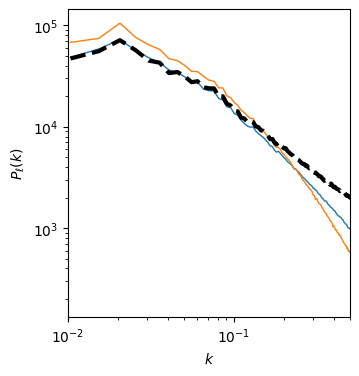

In [12]:
fig = plt.figure(figsize=(8,4))
sub = fig.add_subplot(121)

sub.plot(k, p0k_fid, c='C0', lw=1)    
sub.plot(k, p0k_rsd, c='C1', lw=1)    
sub.plot(r_hod.poles['k'], (r_hod.poles['power_0'].real - r_hod.poles.attrs['shotnoise']), c='k', ls='--', lw=3)

sub.set_xlabel('$k$')
sub.set_xlim(1e-2, 0.5)
sub.set_xscale('log')
sub.set_ylabel('$P_\ell(k)$')
sub.set_yscale('log')
#sub.set_ylim(-1e3, 4e3)

# examine derivatives of bias parameters

alpha knot knot 806581 703771


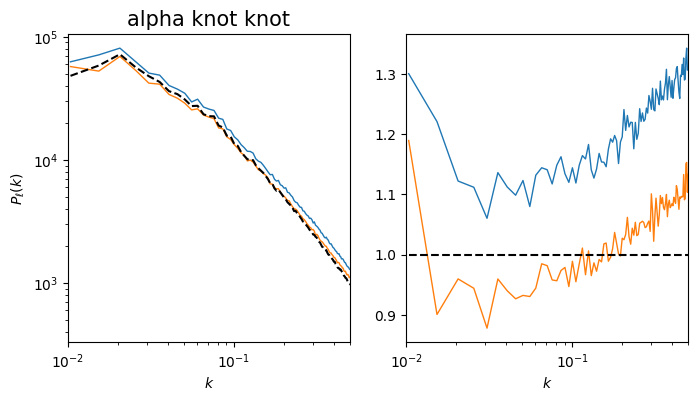

alpha knot filament 862531 980254


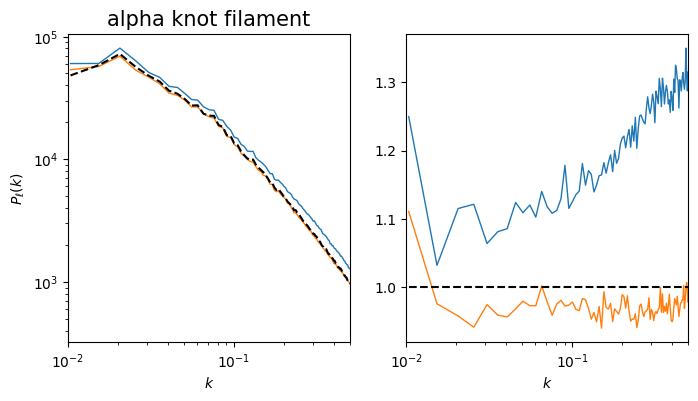

alpha knot sheet 958821 750493


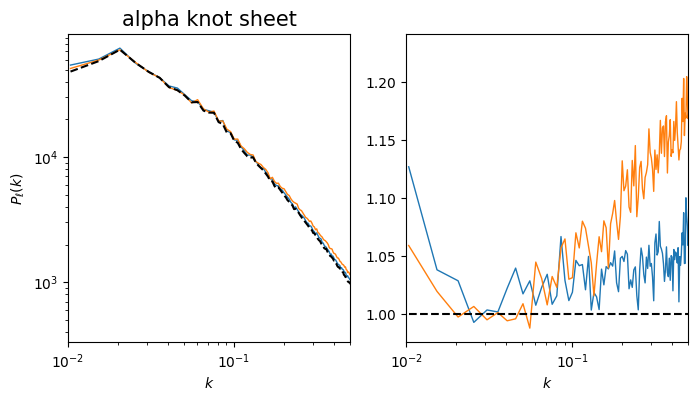

alpha knot void 795643 854612


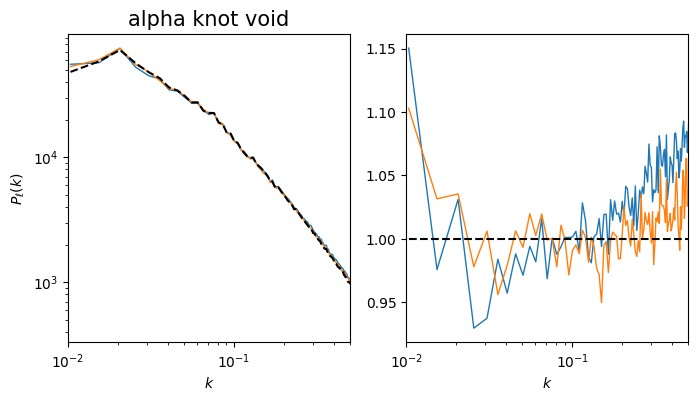

alpha filament knot 894967 1004064


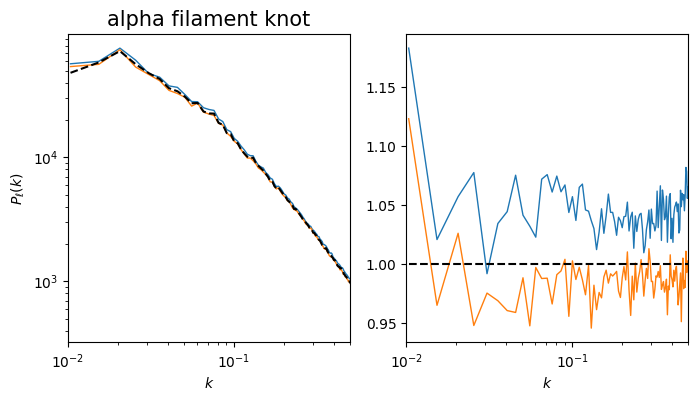

alpha filament filament 940079 859038


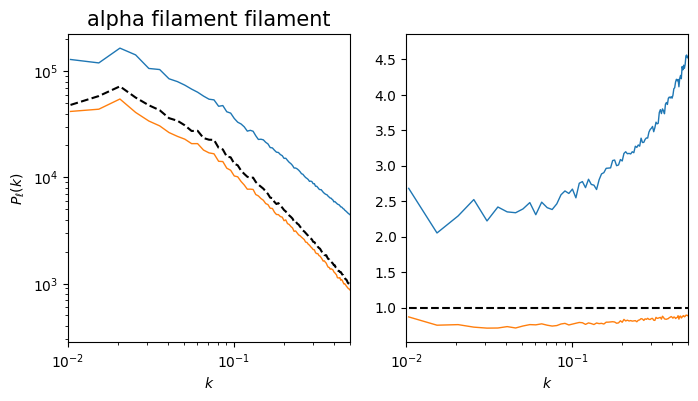

alpha filament sheet 887791 751860


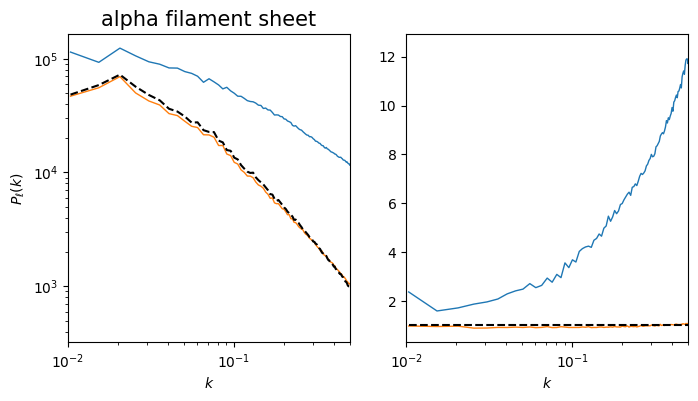

alpha filament void 803645 838415


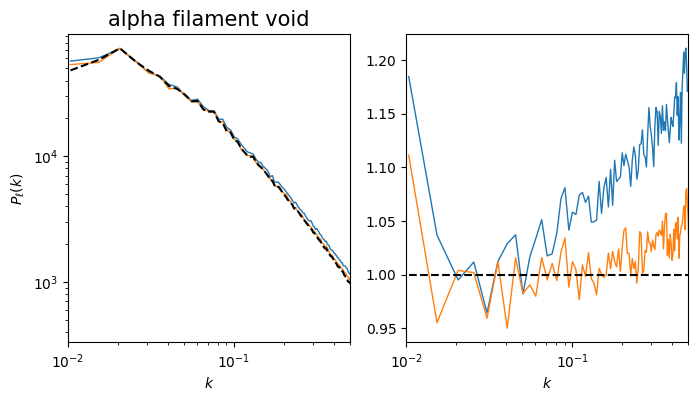

alpha sheet knot 725836 859707


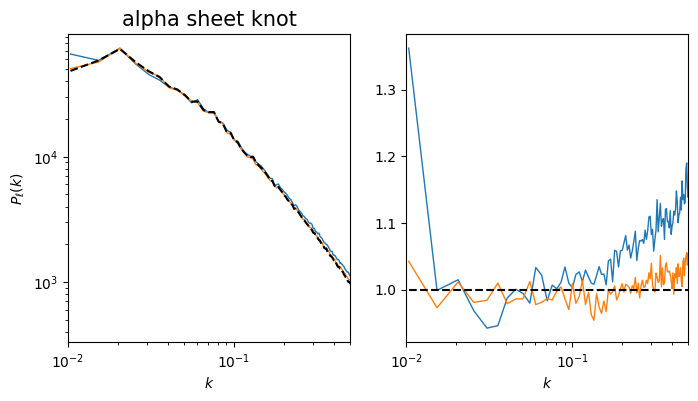

alpha sheet filament 987079 873163


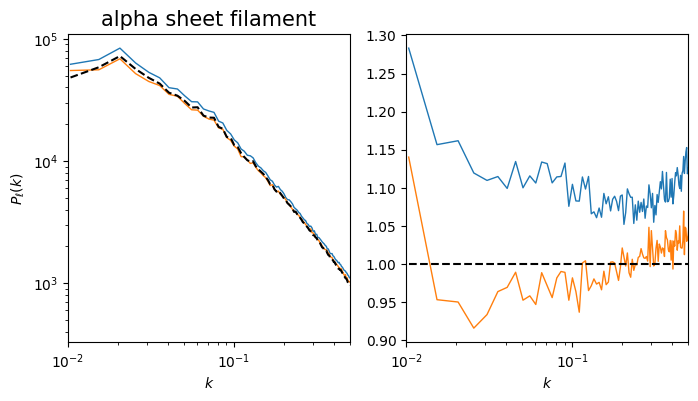

alpha sheet sheet 833431 912435


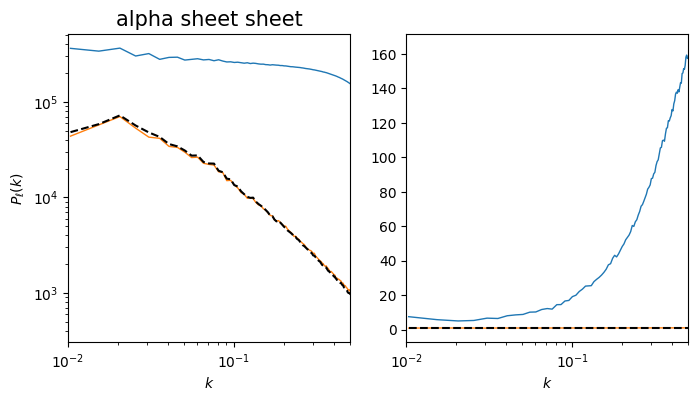

alpha sheet void 859007 919408


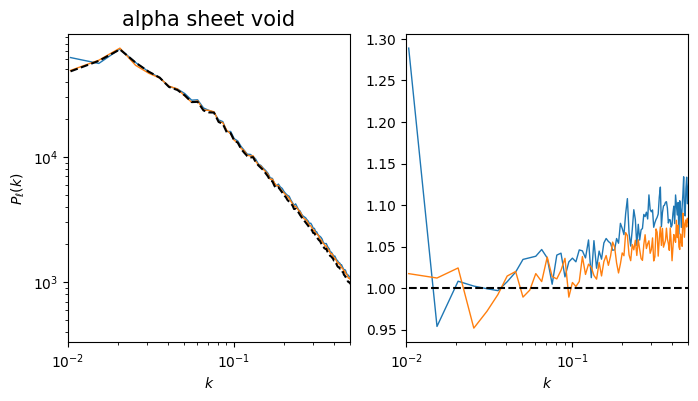

alpha void knot 968369 912925


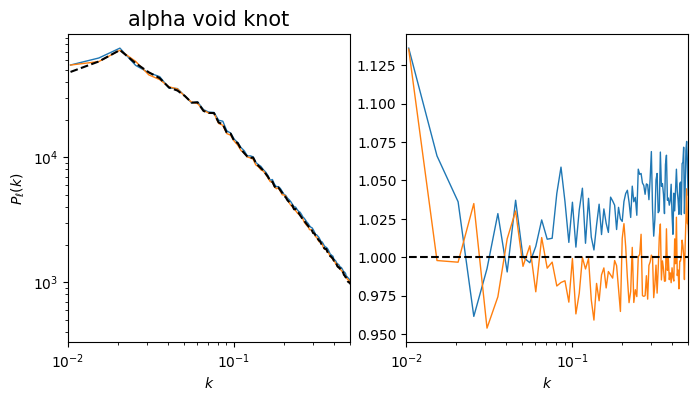

alpha void filament 811145 846009


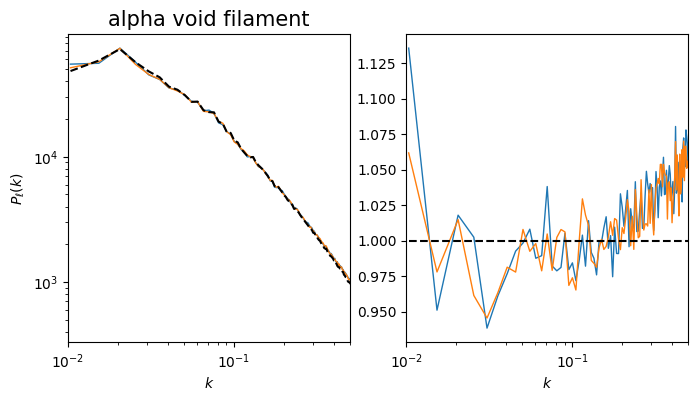

alpha void sheet 671506 818337


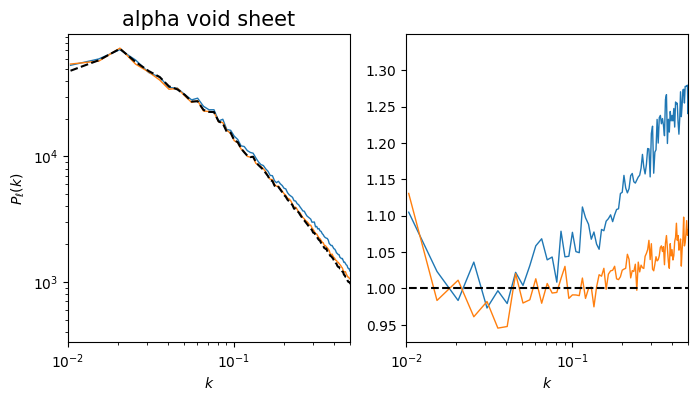

alpha void void 941432 703920


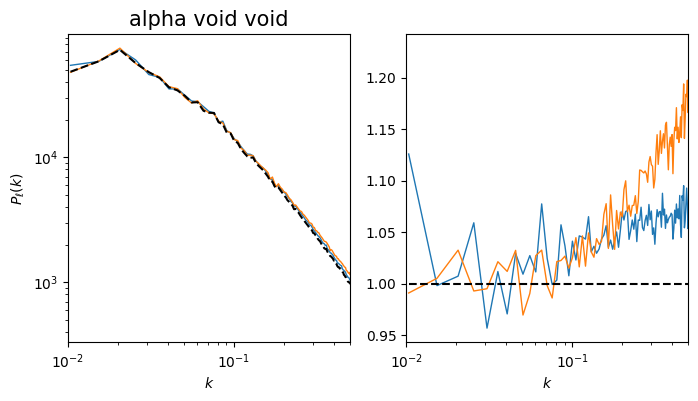

In [14]:
key = 'alpha'
for ienv in range(4): 
    for jenv in range(4): 
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 2
        _, _p0k0, _ng0 = alpt_pk(_tt)
    
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 0.5
        _k, _p0k1, _ng1 = alpt_pk(_tt)

        print('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), _ng0, _ng1)
    
        fig = plt.figure(figsize=(8,4))
        sub = fig.add_subplot(121)
        sub.plot(k, _p0k0, c='C0', lw=1)  
        sub.plot(k, _p0k1, c='C1', lw=1)  
        sub.plot(k, p0k_fid, c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        sub.set_ylabel('$P_\ell(k)$')
        sub.set_yscale('log')
        sub.set_title('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), 
                      fontsize=15)
    
        sub = fig.add_subplot(122)
        sub.plot(k, _p0k0/p0k_fid, c='C0', lw=1)  
        sub.plot(k, _p0k1/p0k_fid, c='C1', lw=1)  
        sub.plot(k, np.ones_like(k), c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        plt.show()

In [ ]:
key = 'nmean'
for ienv in range(4): 
    for jenv in range(4): 
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 2
        _, _p0k0, _ng0 = alpt_pk(_tt)
    
        _tt = copy.deepcopy(theta)
        _tt[key][ienv,jenv] *= 0.5
        print(_tt[key])
        _k, _p0k1, _ng1 = alpt_pk(_tt)

        print('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), _ng0, _ng1)
    
        fig = plt.figure(figsize=(8,4))
        sub = fig.add_subplot(121)
        sub.plot(k, _p0k0, c='C0', lw=1)  
        sub.plot(k, _p0k1, c='C1', lw=1)  
        sub.plot(k, p0k_fid, c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        sub.set_ylabel('$P_\ell(k)$')
        sub.set_yscale('log')
        sub.set_title('%s %s %s' % (key, ['knot', 'filament', 'sheet', 'void'][ienv], ['knot', 'filament', 'sheet', 'void'][jenv]), 
                      fontsize=15)
    
        sub = fig.add_subplot(122)
        sub.plot(k, _p0k0/p0k_fid, c='C0', lw=1)  
        sub.plot(k, _p0k1/p0k_fid, c='C1', lw=1)  
        sub.plot(k, np.ones_like(k), c='k', ls='--') 
        sub.set_xlabel('$k$')
        sub.set_xlim(1e-2, 0.5)
        sub.set_xscale('log')
        plt.show()